In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
gpay = pd.read_csv('GooglePayIndia.csv', sep=',')
gpay

,Unnamed: 0,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,0,gp:AOqpTOEdT_VactGi_J9Q2PEWY7J4XlD7BINhOj9xwOr...,Len Pagnam,https://play-lh.googleusercontent.com/a-/AOh14...,How do add a boarding pass? I see no passes tab.,1,0,2.137.401329300,2021-11-18 17:03:06,Hi Len. Could you try the steps in this guide ...,2021-11-18 17:27:11
1,1,gp:AOqpTOHltpCzXurPoFUgj-a3L-wApC93-fTvocbF9K7...,Benjamin Silva,https://play-lh.googleusercontent.com/a/AATXAJ...,Best,5,0,2.134.392709498,2021-11-18 16:43:34,NaN,NaN
2,2,gp:AOqpTOGTiyxy_FWSQe7eCONa7PsIP6v7cS-xWCL6jFF...,PARVESH MIAR,https://play-lh.googleusercontent.com/a-/AOh14...,All ok,5,0,2.138.406141160,2021-11-18 16:12:42,NaN,NaN
3,3,gp:AOqpTOHllyGnmLGZqPUGokxYncq9kOKoY3Zz_4ZF6b0...,Mikko L.,https://play-lh.googleusercontent.com/a-/AOh14...,"Rasy to use really... But there never, ever sh...",3,0,2.138.406141160,2021-11-18 16:06:35,NaN,NaN
4,4,gp:AOqpTOHjnJ6gAF4NzruhLDGVszAaTKSerVeKt-UtJfM...,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,I still do not understand why your restricting...,3,251,2.134.392709498,2021-11-18 15:48:08,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
34223,34223,gp:AOqpTOEXYnopFG3RZ8fVrBC9yqXnVjmhnDI0Ji99tXb...,Daran Smith,https://play-lh.googleusercontent.com/a-/AOh14...,Like it good app,5,0,2.96.264233179,2019-10-01 02:47:10,NaN,NaN
34224,34224,gp:AOqpTOEVXSkb09ThJsY2TZ0awLgMSCO0qzySxtcT7x9...,Judi Anne,https://play-lh.googleusercontent.com/a-/AOh14...,Excellent very easy to use,5,0,2.95.262992467,2019-10-01 02:38:48,NaN,NaN
34225,34225,gp:AOqpTOHv3DyIxgg2a61I_QQGgjbFodIUp6UlaUpd4M9...,Noori Lal,https://play-lh.googleusercontent.com/a-/AOh14...,Easy to use.,5,0,2.96.264233179,2019-10-01 02:17:54,NaN,NaN
34226,34226,gp:AOqpTOHEnAmESklDXdnvO13QBDl9gOlH4M1qQs-gMYS...,Josh Phillips,https://play-lh.googleusercontent.com/a-/AOh14...,Works how it should,5,0,2.96.264233179,2019-10-01 02:09:34,NaN,NaN


In [3]:
gpay = gpay.rename(columns={'Unnamed: 0' : 'id',
                            'userName' : 'username',
                            'thumbsUpCount' : 'thumbsups',
                            'at' : 'time',
                            'replyContent' : 'reply',
                            'repliedat' : 'reply_time'})

In [4]:
gpay = gpay.drop(columns=['reviewId','userImage', 'reviewCreatedVersion'])

In [5]:
gpay['time'] = pd.to_datetime(gpay['time'])  
gpay['year'] = gpay['time'].dt.year
gpay['month'] = gpay['time'].dt.month
gpay['month_name'] = gpay['time'].dt.month_name()
gpay['day'] = gpay['time'].dt.day
gpay['day_name'] = gpay['time'].dt.day_name()
gpay['hour'] = gpay['time'].dt.hour

gpay['repliedAt'] = pd.to_datetime(gpay['repliedAt'])  
gpay['reply_yr'] = gpay['repliedAt'].dt.year
gpay['reply_month'] = gpay['repliedAt'].dt.month
gpay['reply_month_name'] = gpay['repliedAt'].dt.month_name()
gpay['reply_day'] = gpay['repliedAt'].dt.day
gpay['reply_day_name'] = gpay['repliedAt'].dt.day_name()
gpay['reply_hour'] = gpay['repliedAt'].dt.hour

In [6]:
gpay['sentiment'] = gpay['score'].apply(lambda x:'Positive' if x>=4 else 'Neutral' if x==3 else 'Negative')
gpay['late_night'] = gpay['hour'].apply(lambda x: 'Late-Night' if x<6 or x>=23 else 'Day')
gpay['week'] = gpay['day_name'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')
gpay['length'] = gpay['content'].astype(str).str.len()
review_time = pd.to_datetime(gpay[['year','month','day','hour']])
reply_time = pd.to_datetime(gpay[['reply_yr','reply_month','reply_day','reply_hour']].rename(
    columns={'reply_yr': 'year', 'reply_month': 'month', 'reply_day': 'day', 'reply_hour': 'hour'}
))
gpay['resp_hour'] = (reply_time - review_time).dt.total_seconds()/3600

## 🧭 SECTION 1 — Overall App Health (Start of Story)


### Q1. How are ratings distributed across 1★–5★?


<Axes: xlabel='score', ylabel='count'>

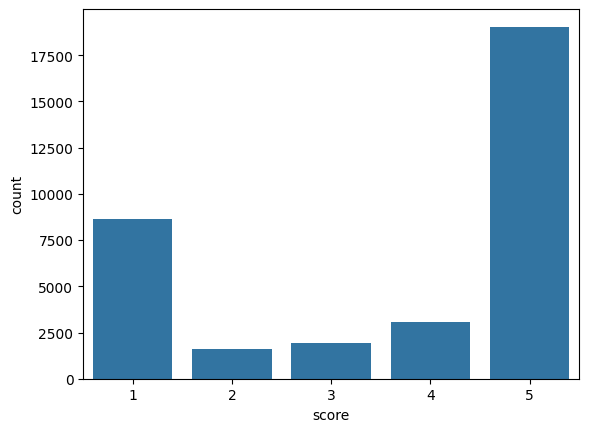

In [7]:
sns.countplot(data=gpay, x='score')

### Q2. What proportion of reviews are Positive, Neutral, and Negative?


<Axes: ylabel='count'>

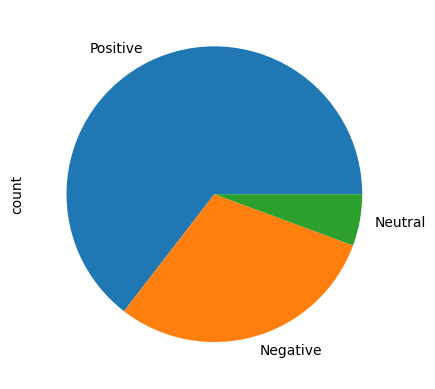

In [9]:
gpay['sentiment'].value_counts().plot.pie()

### Q3. Which rating contributes most to total helpful votes?


<Axes: ylabel='score'>

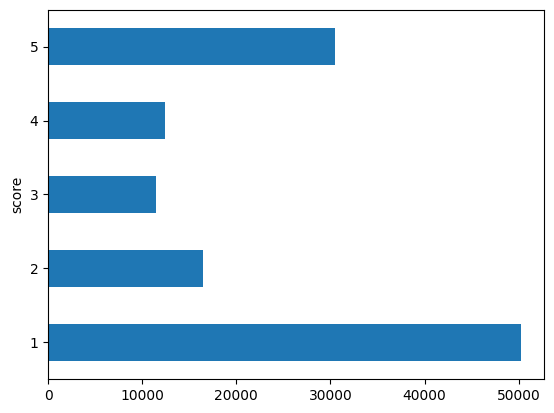

In [11]:
gpay.groupby('score')['thumbsups'].sum().plot(kind='barh')

### Q4. Do extreme ratings dominate over middle ratings?


<Axes: ylabel='type'>

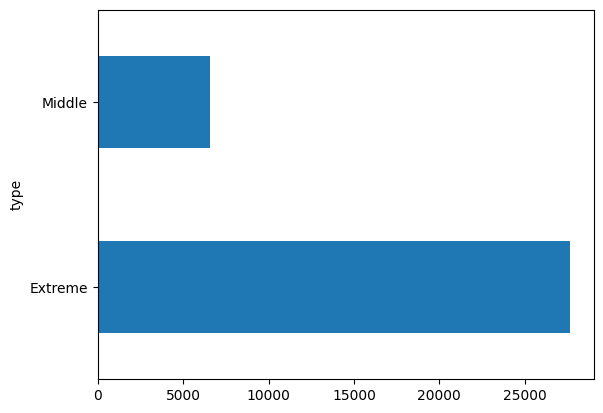

In [12]:
gpay['type'] = gpay['score'].apply(lambda x:'Extreme' if x in [1,5] else 'Middle')
gpay['type'].value_counts().plot(kind='barh')

## ⏰ SECTION 2 — When Users Face Problems (Time Behaviour)


### Q5. How does review volume change month-to-month?


<Axes: ylabel='month_name'>

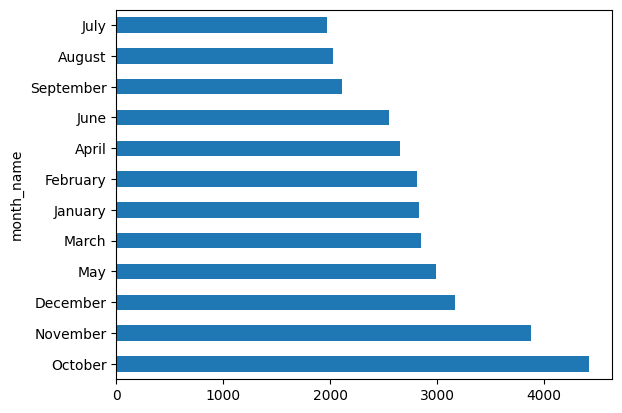

In [13]:
gpay['month_name'].value_counts().plot(kind='barh')

### Q6. How does average rating vary across months?


<Axes: ylabel='month_name'>

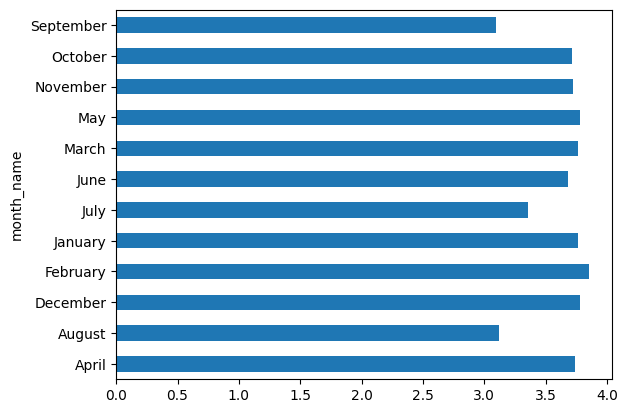

In [16]:
gpay.groupby('month_name')['score'].mean().plot(kind='barh')

### Q7. Which month experienced the highest complaints?


<Axes: ylabel='month_name'>

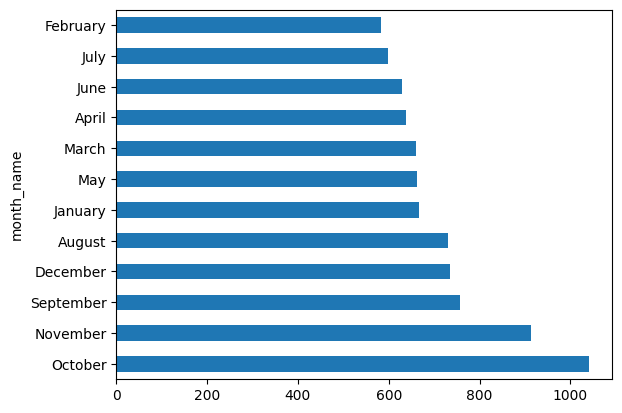

In [17]:
gpay[gpay['score']==1]['month_name'].value_counts().plot(kind='barh')

### Q8. Which day of week receives most reviews?


<Axes: ylabel='day_name'>

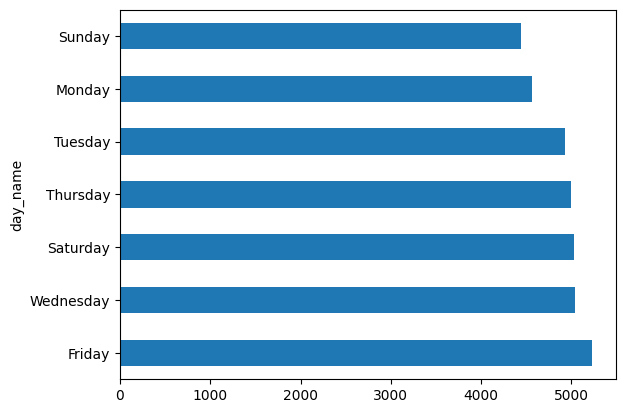

In [18]:
gpay['day_name'].value_counts().plot(kind='barh')

### Q9. Which day has worst ratings?


<Axes: ylabel='day_name'>

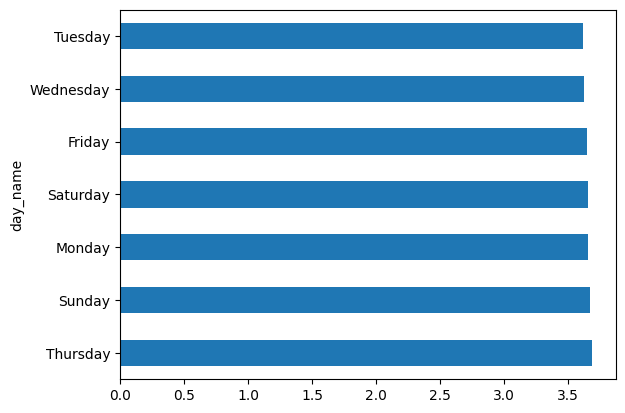

In [21]:
gpay.groupby('day_name')['score'].mean().sort_values(ascending=False).plot(kind='barh')

### Q10. Do weekends differ from weekdays in rating behaviour?


<Axes: ylabel='week'>

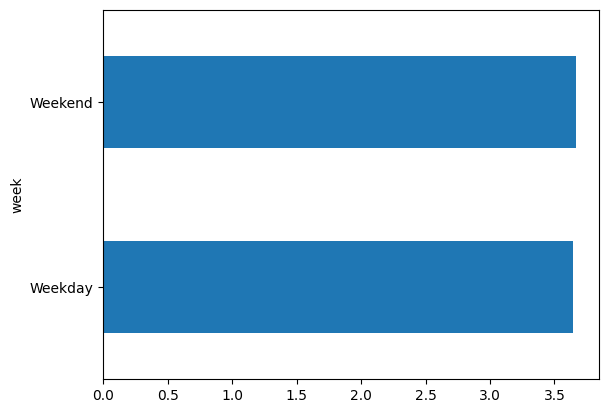

In [22]:
gpay.groupby('week')['score'].mean().plot(kind='barh')

### Q11. At what hour are most reviews posted?


<Axes: xlabel='hour', ylabel='Count'>

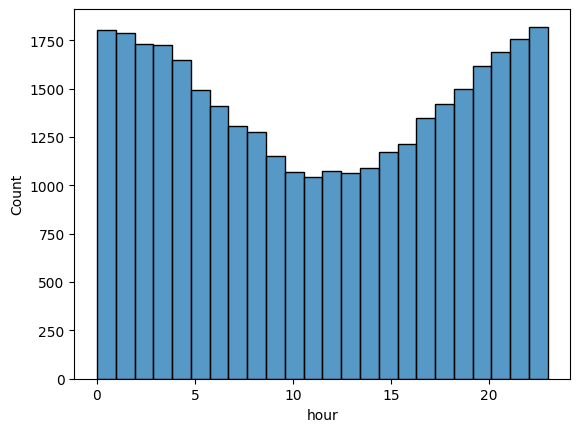

In [23]:
sns.histplot(gpay['hour'], bins=24)

### Q12. At what hour do most 1★ reviews occur?


<Axes: ylabel='hour'>

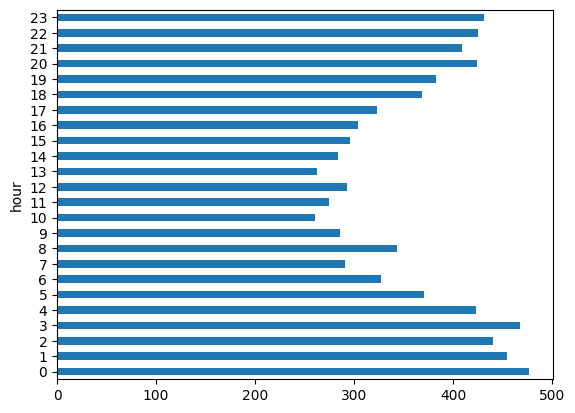

In [25]:
gpay[gpay['score']==1]['hour'].value_counts().sort_index().plot(kind='barh')

### Q13. At what hour is rating highest?


<Axes: xlabel='hour'>

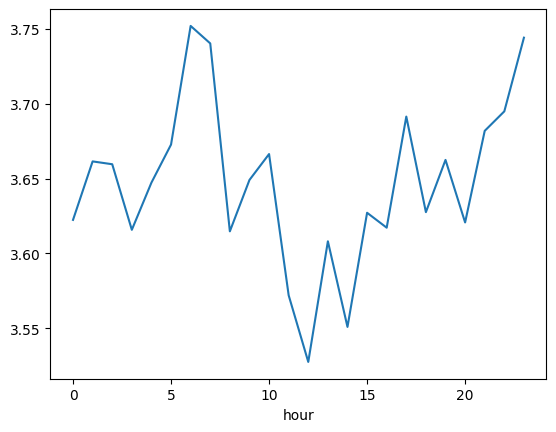

In [26]:
gpay.groupby('hour')['score'].mean().plot()

### Q14. Is there a specific daily “failure window”?


<Axes: xlabel='hour', ylabel='day_name'>

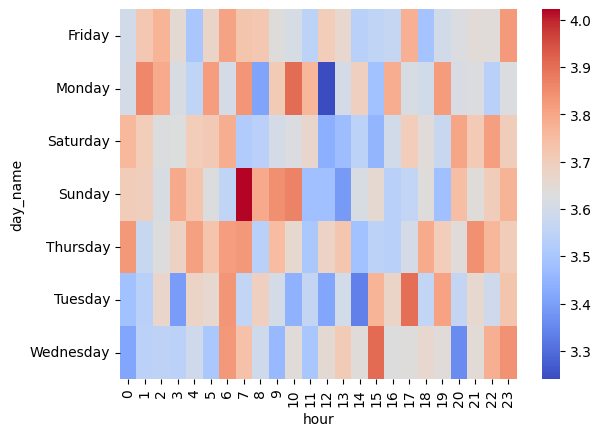

In [28]:
pivot = gpay.pivot_table(values='score', index='day_name', columns='hour', aggfunc='mean')
sns.heatmap(pivot, cmap='coolwarm')

## 👍 SECTION 3 — Community Agreement (Helpful Votes)


### Q15. How do helpful votes vary across ratings?


<Axes: xlabel='score', ylabel='thumbsups'>

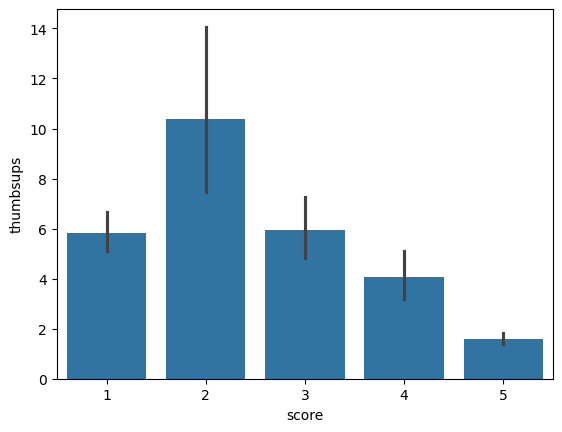

In [29]:
sns.barplot(data=gpay, x='score', y='thumbsups')

### Q16. Do negative reviews receive more agreement than positive?


<Axes: xlabel='sentiment', ylabel='thumbsups'>

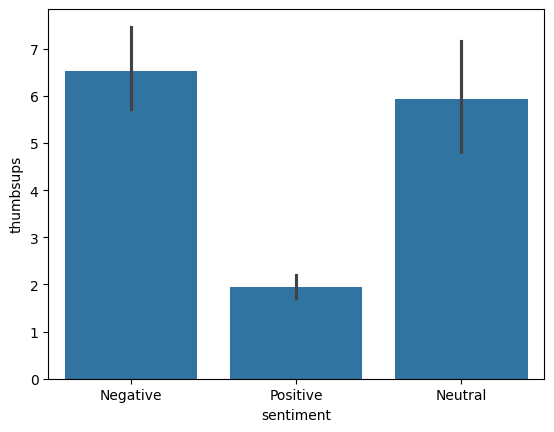

In [30]:
sns.barplot(data=gpay, x='sentiment', y='thumbsups')

### Q17. Distribution of helpful votes — few viral vs many ignored?


<Axes: xlabel='thumbsups', ylabel='Count'>

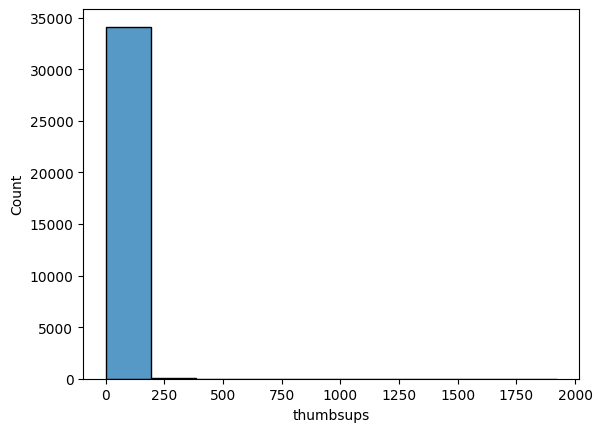

In [32]:
sns.histplot(gpay['thumbsups'], bins=10)

### Q18. Do longer reviews receive more helpful votes?


<Axes: xlabel='thumbsups', ylabel='length'>

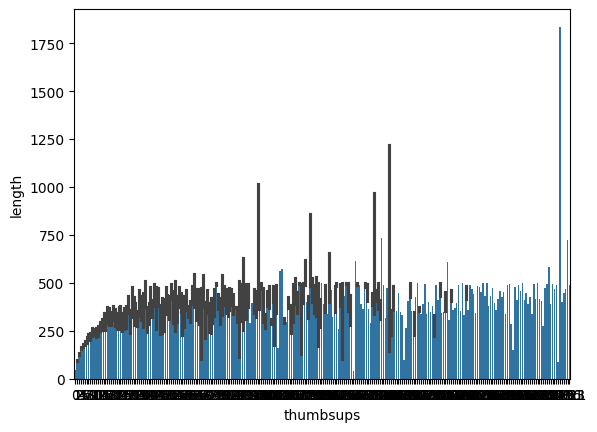

In [35]:
sns.barplot(data=gpay, y='length', x='thumbsups')

## 📝 SECTION 4 — Review Content Behaviour


### Q19. How does review length vary by rating?


<Axes: xlabel='score', ylabel='length'>

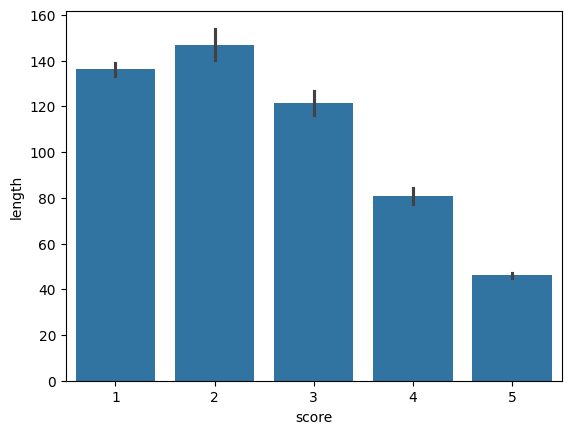

In [36]:
sns.barplot(data=gpay, y='length', x='score')

### Q20. Are negative reviews longer than positive reviews?


<Axes: ylabel='sentiment'>

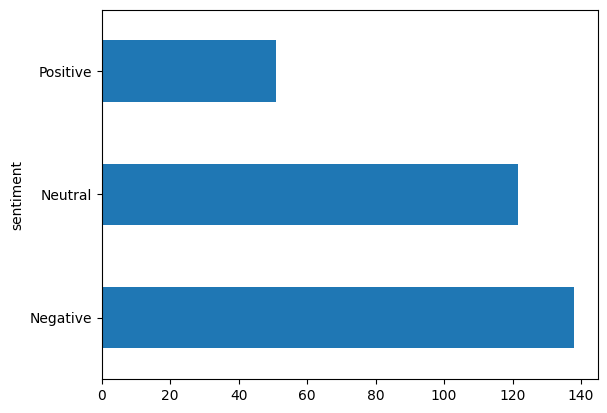

In [37]:
gpay.groupby('sentiment')['length'].mean().plot(kind='barh')

### Q21. Which rating category has the most detailed feedback?


<Axes: ylabel='score'>

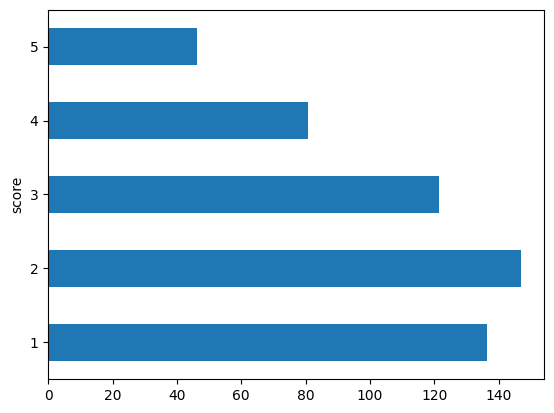

In [38]:
gpay.groupby('score')['length'].mean().plot(kind='barh')

## 🧑‍💻 SECTION 5 — Developer Support Behaviour


### Q22. What proportion of reviews receive a developer reply?


In [39]:
gpay['replied'] = gpay['reply'].notna()

<Axes: ylabel='count'>

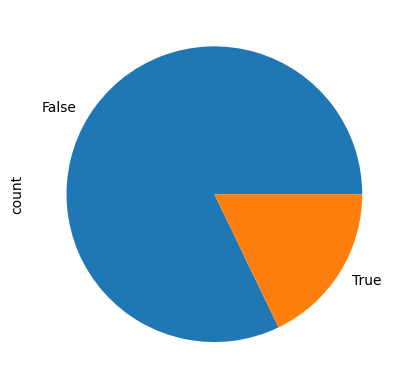

In [40]:
gpay['replied'].value_counts().plot.pie()

### Q23. Which ratings get replies most frequently?


<Axes: xlabel='score', ylabel='count'>

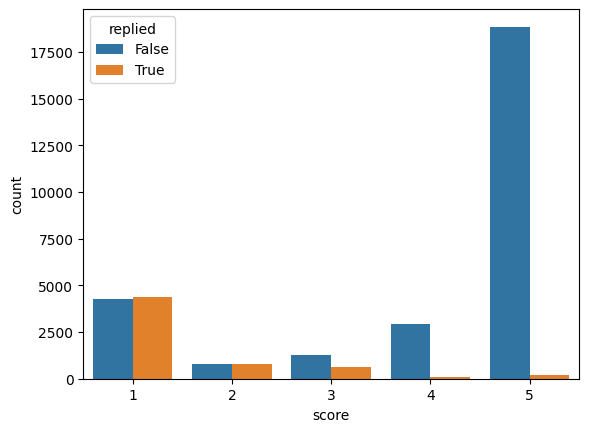

In [42]:
sns.countplot(data=gpay, x='score', hue='replied')

### Q24. Does the company prioritize 1★ reviews?


<Axes: xlabel='score', ylabel='replied'>

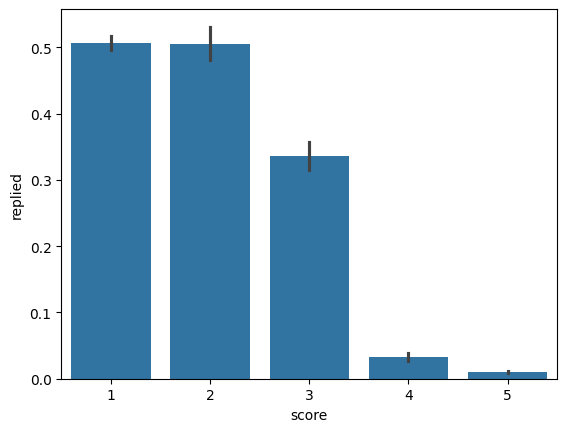

In [43]:
sns.barplot(data=gpay, x='score', y='replied')

### Q25. Do positive reviews get ignored?


## ⏱️ SECTION 6 — Support Efficiency


### Q26. How long does the company take to reply (distribution)?


<Axes: xlabel='resp_hour', ylabel='Count'>

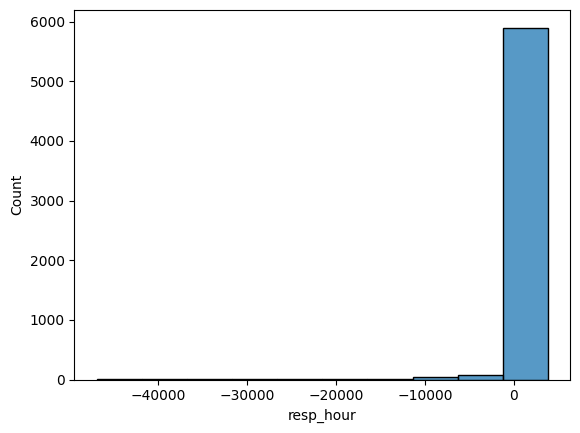

In [44]:
sns.histplot(gpay['resp_hour'], bins=10)

### Q27. Does response time vary by rating?


<Axes: xlabel='score', ylabel='resp_hour'>

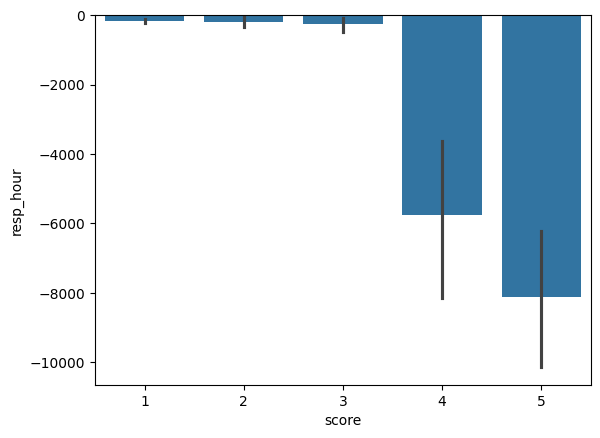

In [45]:
sns.barplot(data=gpay, x='score', y='resp_hour')

### Q28. Does response time vary by day of week?


<Axes: xlabel='day_name', ylabel='resp_hour'>

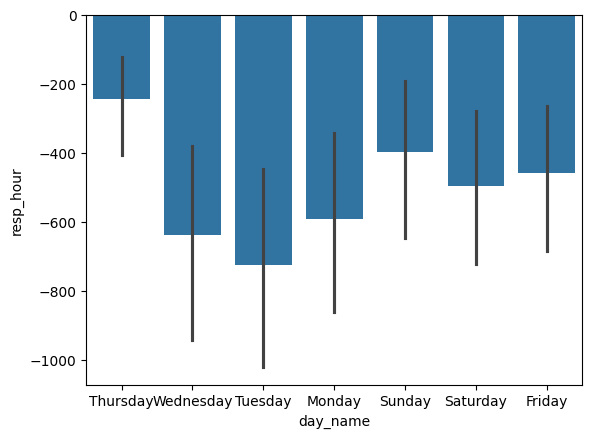

In [48]:
sns.barplot(data=gpay, x='day_name', y='resp_hour')

### Q29. Are weekend complaints handled slower?


<Axes: xlabel='week', ylabel='resp_hour'>

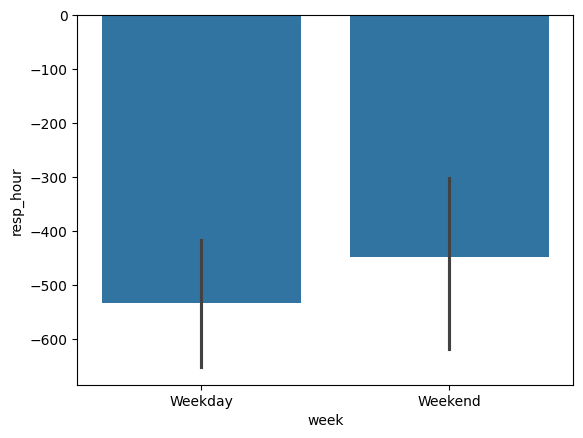

In [49]:
sns.barplot(data=gpay, x='week', y='resp_hour')

### Q30. Does response timing match complaint timing?


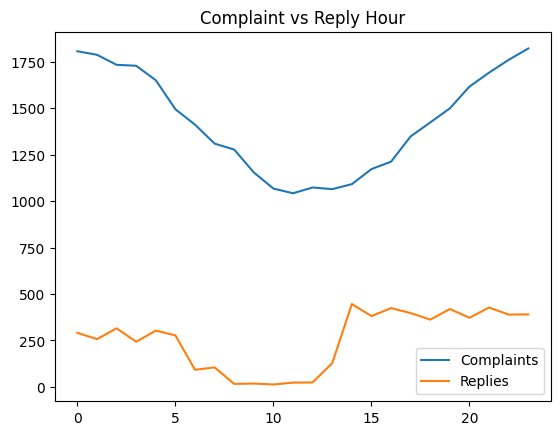

In [52]:
plt.plot(gpay['hour'].value_counts().sort_index(),label='Complaints')
plt.plot(gpay['reply_hour'].value_counts().sort_index(),label='Replies')
plt.legend(); plt.title("Complaint vs Reply Hour"); plt.show()

## 🔗 SECTION 7 — Impact of Reply


### Q31. Do replied reviews receive more helpful votes?


<Axes: xlabel='replied', ylabel='thumbsups'>

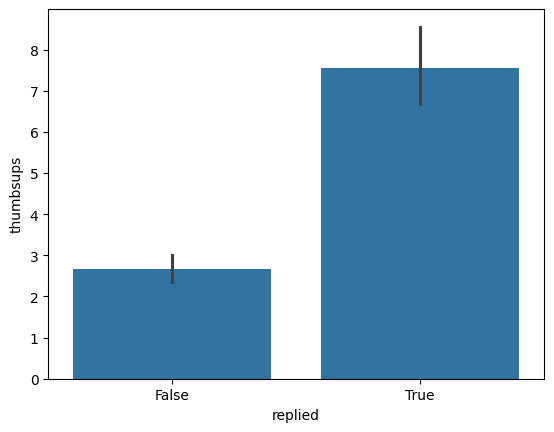

In [53]:
sns.barplot(data=gpay, x='replied', y='thumbsups')

### Q32. Are unreplied complaints more viral?


<Axes: xlabel='replied', ylabel='thumbsups'>

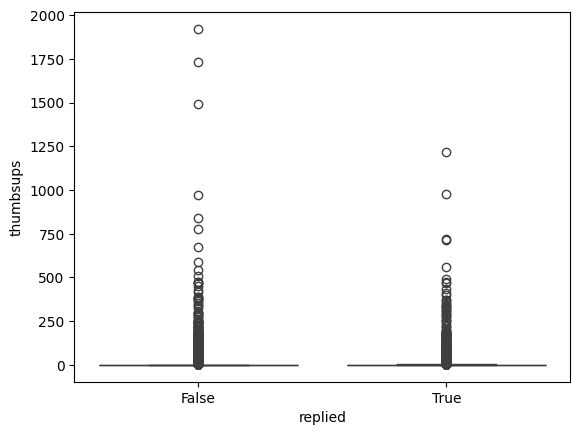

In [54]:
sns.boxplot(data=gpay, x='replied', y='thumbsups')

### Q33. Does faster reply correlate with higher ratings?


<Axes: xlabel='resp_hour', ylabel='score'>

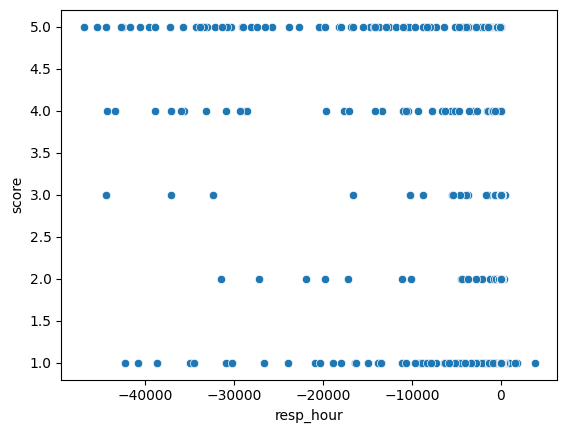

In [56]:
sns.scatterplot(data=gpay, x='resp_hour', y='score')

## 👥 SECTION 8 — User Behaviour


### Q34. Are reviews evenly distributed across users or dominated by few users?


<Axes: >

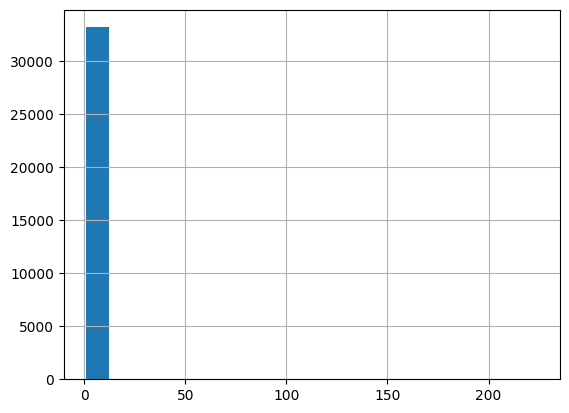

In [57]:
gpay['username'].value_counts().hist(bins=20)

### Q35. Do frequent reviewers rate differently than occasional users?


In [58]:
user_avg = gpay.groupby('username')['score'].mean()

<Axes: xlabel='score', ylabel='Count'>

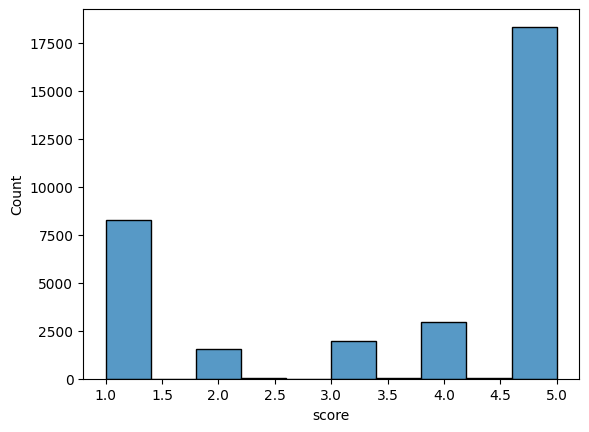

In [59]:
sns.histplot(data=user_avg, bins=10)

## 🧠 FINAL STORY (Most Important Plots)


### Q36. Worst day-hour combination for ratings


<Axes: xlabel='hour', ylabel='day_name'>

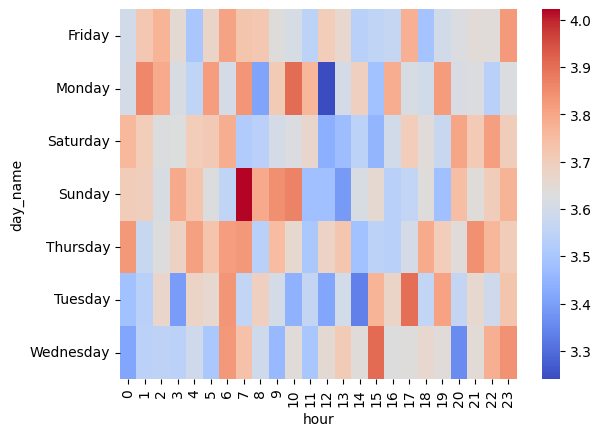

In [61]:
worst = gpay.pivot_table(values='score', index='day_name', columns='hour', aggfunc='mean')
sns.heatmap(data=worst, cmap='coolwarm')

### Q37. Best performing time window


<Axes: xlabel='hour', ylabel='day_name'>

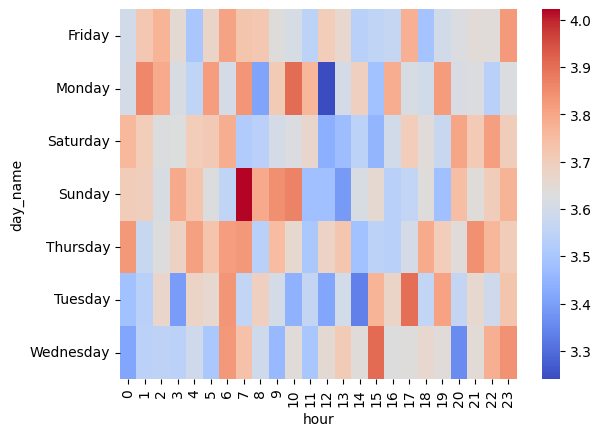

In [62]:
best = gpay.pivot_table(values='score', index='day_name', columns='hour', aggfunc='mean')
sns.heatmap(data=worst, cmap='coolwarm')

### Q38. Complaint time vs reply time comparison


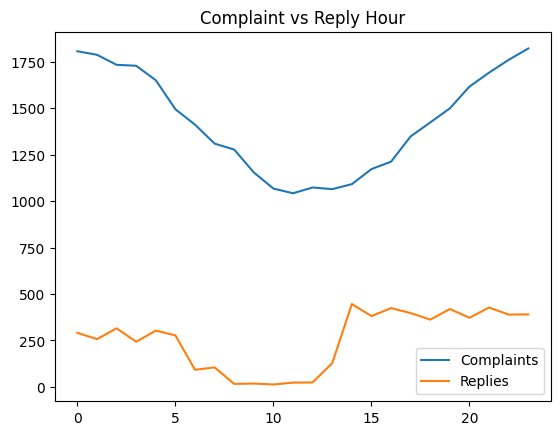

In [63]:
plt.plot(gpay['hour'].value_counts().sort_index(),label='Complaints')
plt.plot(gpay['reply_hour'].value_counts().sort_index(),label='Replies')
plt.legend(); plt.title("Complaint vs Reply Hour"); plt.show()

### Q39. Does support activity align with user frustration periods?


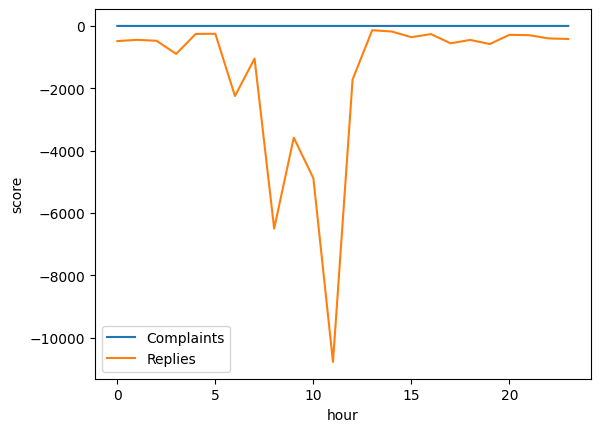

In [67]:
sns.lineplot(gpay.groupby('hour')['score'].mean(),label='Complaints')
sns.lineplot(gpay.groupby('reply_hour')['resp_hour'].mean(),label='Replies')
plt.legend(); plt.show()

### Q40. Overall trust indicators (rating + helpful votes + replies)

In [68]:
metrics=pd.Series({'Avg Rating':gpay['score'].mean(),
                   'Avg Helpful Votes':gpay['thumbsups'].mean(),
                   'Reply Rate':gpay['replied'].mean()*100})

<Axes: >

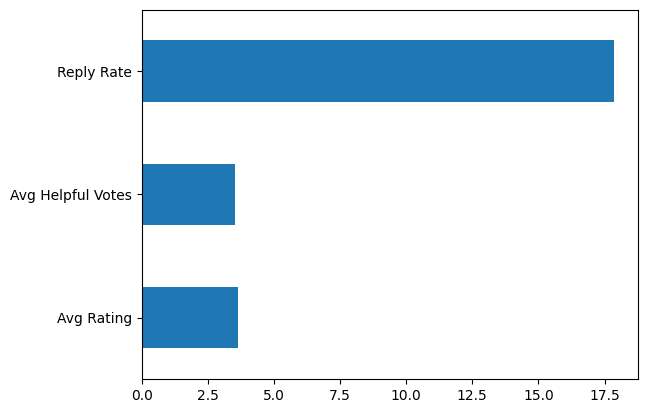

In [70]:
metrics.plot(kind='barh')